# IntelliStock Advanced Analytics Dashboard
## Comprehensive ML Insights & Visualization

This notebook provides:
- 📈 **Trend Analysis** - Growth classification
- 📊 **Moving Average** - Smoothed trends
- 📅 **Seasonality** - Weekly patterns
- ⚠️ **Anomaly Detection** - Outlier identification
- 📉 **Forecast Accuracy** - Model performance metrics
- 💹 **Growth Rate** - Period-over-period analysis

## 1️⃣ Setup & Database Connection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.linear_model import LinearRegression
from scipy import stats
from urllib.parse import quote_plus
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Database configuration
DB_USER = "postgres"
DB_PASSWORD_RAW = "Pruthvi@45"
DB_HOST = "127.0.0.1"
DB_PORT = "5432"
DB_NAME = "intellistock_db"

# URL encode password to handle special characters
DB_PASSWORD = quote_plus(DB_PASSWORD_RAW)

# Create database connection
engine = create_engine(f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("✅ Database connected successfully!")

✅ Database connected successfully!


## 2️⃣ Load Sales Data

In [2]:
# Load sales data
query = """
    SELECT 
        id, 
        product_id, 
        quantity, 
        total_amount, 
        sale_date
    FROM sales
    ORDER BY sale_date
"""

df = pd.read_sql(query, engine)
df['sale_date'] = pd.to_datetime(df['sale_date'])

print(f"📊 Total records: {len(df)}")
print(f"📅 Date range: {df['sale_date'].min()} to {df['sale_date'].max()}")
print(f"\n🔍 Data Preview:")
df.head(10)

📊 Total records: 3
📅 Date range: 2026-03-01 00:00:00 to 2026-03-02 00:00:00

🔍 Data Preview:


,id,product_id,quantity,total_amount,sale_date
0,1,1,2,100.0,2026-03-01
1,2,1,1,45.0,2026-03-02
2,3,1,1,45.0,2026-03-02


## 3️⃣ Daily Sales Aggregation

In [4]:
# Aggregate daily sales
daily_sales = df.groupby('sale_date').agg({
    'quantity': 'sum',
    'total_amount': 'sum'
}).reset_index()

daily_sales.columns = ['date', 'quantity', 'revenue']

print(f"📈 Daily aggregated records: {len(daily_sales)}")
print(daily_sales.head(10))

📈 Daily aggregated records: 2
        date  quantity  revenue
0 2026-03-01         2    100.0
1 2026-03-02         2     90.0


## 4️⃣ Trend Analysis - Sales Direction

🎯 Trend Status: ➖ Stable
📊 Slope: 0.0000 units/day
📍 Interpretation: Daily sales changing by 0.00 units per day


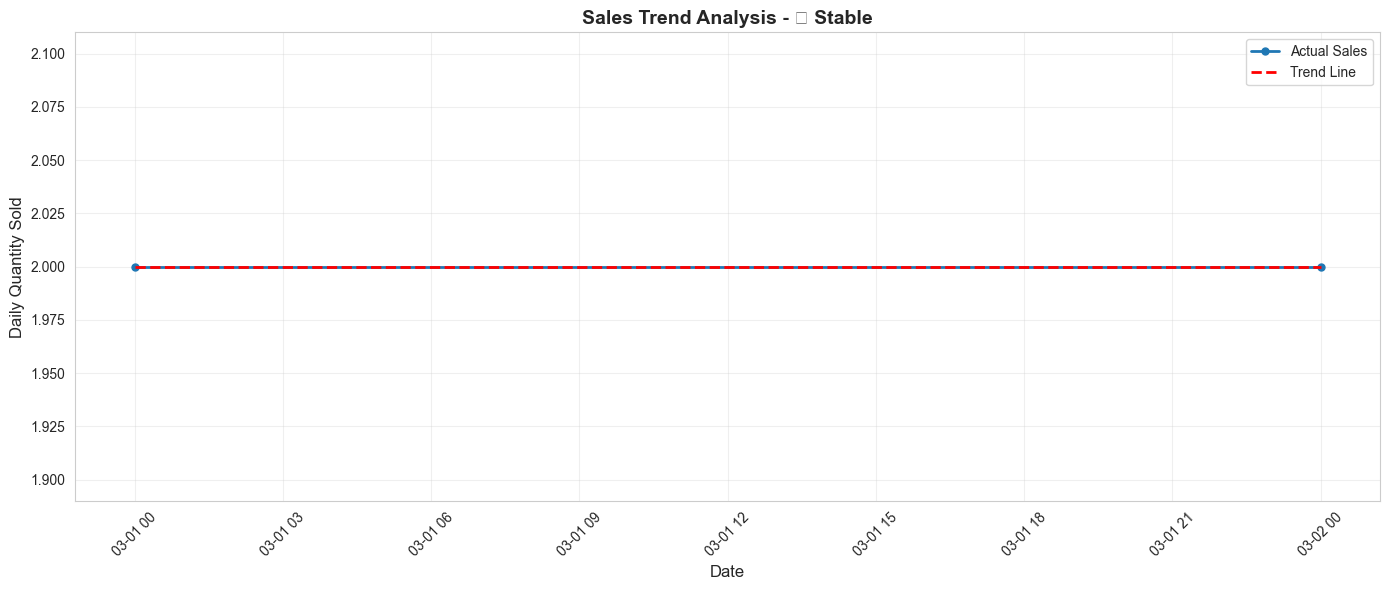

In [5]:
# Trend analysis using linear regression
daily_sales['day_number'] = np.arange(len(daily_sales))

X = daily_sales[['day_number']].values
y = daily_sales['quantity'].values

model = LinearRegression()
model.fit(X, y)

slope = float(model.coef_[0])
intercept = float(model.intercept_)

# Classify trend
if slope > 0.5:
    trend_status = "📈 Growing"
elif slope < -0.5:
    trend_status = "📉 Declining"
else:
    trend_status = "➖ Stable"

print(f"🎯 Trend Status: {trend_status}")
print(f"📊 Slope: {slope:.4f} units/day")
print(f"📍 Interpretation: Daily sales changing by {slope:.2f} units per day")

# Visualization
predicted = model.predict(X)

plt.figure(figsize=(14, 6))
plt.plot(daily_sales['date'], daily_sales['quantity'], 'o-', label='Actual Sales', linewidth=2, markersize=5)
plt.plot(daily_sales['date'], predicted, 'r--', label='Trend Line', linewidth=2)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Quantity Sold', fontsize=12)
plt.title(f'Sales Trend Analysis - {trend_status}', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5️⃣ Moving Average - Noise Reduction

In [ ]:
# Calculate moving averages
daily_sales['ma_7'] = daily_sales['quantity'].rolling(window=7, center=True).mean()
daily_sales['ma_14'] = daily_sales['quantity'].rolling(window=14, center=True).mean()

# Visualization
plt.figure(figsize=(14, 7))
plt.plot(daily_sales['date'], daily_sales['quantity'], 'o', label='Actual', alpha=0.6, markersize=6)
plt.plot(daily_sales['date'], daily_sales['ma_7'], '-', label='7-Day Moving Average', linewidth=2)
plt.plot(daily_sales['date'], daily_sales['ma_14'], '-', label='14-Day Moving Average', linewidth=2)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Quantity', fontsize=12)
plt.title('Moving Average - Smoothed Trend Analysis', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("✅ 7-day and 14-day moving averages computed")
print(daily_sales[['date', 'quantity', 'ma_7', 'ma_14']].tail(10))

## 6️⃣ Seasonality Analysis - Weekly Patterns

In [ ]:
# Extract day of week
df['day_of_week'] = df['sale_date'].dt.day_name()
df['weekday_order'] = df['sale_date'].dt.weekday  # Monday=0, Sunday=6

# Calculate statistics by day of week
weekly_pattern = df.groupby('day_of_week').agg({
    'quantity': ['mean', 'sum', 'count'],
    'total_amount': 'mean'
}).round(2)

# Reorder for clarity
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg = df.groupby('day_of_week')['quantity'].mean().reindex(day_order)

print("📊 Weekly Sales Pattern:")
print(daily_avg)

peak_day = daily_avg.idxmax()
low_day = daily_avg.idxmin()

print(f"\n🔔 Peak Sales Day: {peak_day} (avg: {daily_avg[peak_day]:.2f} units)")
print(f"📉 Lowest Sales Day: {low_day} (avg: {daily_avg[low_day]:.2f} units)")

# Visualization
plt.figure(figsize=(12, 6))
colors = ['#ff9999' if day == low_day else '#99ff99' if day == peak_day else '#99ccff' for day in day_order]
daily_avg.plot(kind='bar', color=colors, edgecolor='black', linewidth=1.5)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Average Quantity Sold', fontsize=12)
plt.title('Weekly Seasonality Pattern', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 7️⃣ Anomaly Detection - Outlier Spikes

In [ ]:
# Calculate statistics
mean_qty = daily_sales['quantity'].mean()
std_qty = daily_sales['quantity'].std()

# Define anomaly threshold (2-sigma)
threshold = mean_qty + (2 * std_qty)
lower_threshold = mean_qty - (2 * std_qty)

# Identify anomalies
anomalies = daily_sales[(daily_sales['quantity'] > threshold) | (daily_sales['quantity'] < lower_threshold)]

print(f"📊 Statistical Summary:")
print(f"Mean: {mean_qty:.2f} units")
print(f"Std Dev: {std_qty:.2f}")
print(f"Upper Threshold (mean + 2σ): {threshold:.2f}")
print(f"Lower Threshold (mean - 2σ): {lower_threshold:.2f}")
print(f"\n⚠️ Anomalies Detected: {len(anomalies)}")
print(anomalies[['date', 'quantity']])

# Visualization
plt.figure(figsize=(14, 7))
plt.plot(daily_sales['date'], daily_sales['quantity'], 'o-', label='Daily Sales', linewidth=2, color='blue')
plt.axhline(mean_qty, color='green', linestyle='--', linewidth=2, label='Mean')
plt.axhline(threshold, color='red', linestyle='--', linewidth=2, label='Upper Threshold (2σ)')
plt.axhline(lower_threshold, color='orange', linestyle='--', linewidth=2, label='Lower Threshold (-2σ)')
plt.fill_between(daily_sales['date'], lower_threshold, threshold, alpha=0.2, color='green', label='Normal Range')

# Highlight anomalies
if len(anomalies) > 0:
    plt.scatter(anomalies['date'], anomalies['quantity'], color='red', s=100, zorder=5, label='Anomalies')

plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Quantity', fontsize=12)
plt.title('Anomaly Detection - Statistical Outliers', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8️⃣ Growth Rate Analysis

In [ ]:
# Week-over-week growth
weekly_sales = daily_sales.set_index('date').resample('W')['quantity'].sum()

if len(weekly_sales) > 1:
    wow_growth = ((weekly_sales.iloc[-1] - weekly_sales.iloc[-2]) / weekly_sales.iloc[-2] * 100)
else:
    wow_growth = 0

# Overall growth
first_week_total = daily_sales.iloc[:7]['quantity'].sum()
last_week_total = daily_sales.iloc[-7:]['quantity'].sum()
overall_growth = ((last_week_total - first_week_total) / first_week_total * 100) if first_week_total > 0 else 0

print("📈 Growth Rate Analysis:")
print(f"Week-over-Week Growth: {wow_growth:+.2f}%")
print(f"Overall Growth (First Week vs Last Week): {overall_growth:+.2f}%")
print(f"First Week Total: {first_week_total:.2f} units")
print(f"Last Week Total: {last_week_total:.2f} units")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Weekly sales
weekly_sales.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Weekly Total Sales', fontsize=12, fontweight='bold')
ax1.set_ylabel('Quantity', fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

# Growth rate
growth_periods = ['First Week', 'Last Week']
growth_values = [first_week_total, last_week_total]
colors_growth = ['#ff9999', '#99ff99']
bars = ax2.bar(growth_periods, growth_values, color=colors_growth, edgecolor='black', linewidth=1.5)
ax2.set_title(f'Overall Growth: {overall_growth:+.1f}%', fontsize=12, fontweight='bold')
ax2.set_ylabel('Total Quantity', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, value in zip(bars, growth_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{value:.0f}', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 9️⃣ Forecast Accuracy Metrics

In [ ]:
# Predict on all historical data
predictions = model.predict(X)

# Calculate MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((y - predictions) / (y + 0.001))) * 100
accuracy = 100 - mape

# Calculate RMSE
rmse = np.sqrt(np.mean((y - predictions) ** 2))

print("📊 Model Performance Metrics:")
print(f"MAPE Error: {mape:.2f}%")
print(f"Accuracy: {accuracy:.2f}%")
print(f"RMSE: {rmse:.2f}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Actual vs Predicted
ax1.plot(daily_sales['date'], y, 'o-', label='Actual', linewidth=2, markersize=5)
ax1.plot(daily_sales['date'], predictions, 's--', label='Predicted', linewidth=2, markersize=4)
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Quantity', fontsize=11)
ax1.set_title('Forecast vs Actual', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Metrics display
metrics_text = f"""Model Performance
━━━━━━━━━━━━━━━━━━
Accuracy:  {accuracy:.2f}%
MAPE Error: {mape:.2f}%
RMSE:      {rmse:.2f}
Data Points: {len(y)}"""

ax2.text(0.1, 0.5, metrics_text, fontsize=12, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), family='monospace')
ax2.axis('off')

plt.tight_layout()
plt.show()

## 🔟 Integrated Dashboard Summary

In [ ]:
# Create comprehensive dashboard summary
dashboard_summary = {
    "trend": {
        "status": trend_status,
        "slope": round(slope, 4),
        "interpretation": f"Daily sales changing by {slope:.2f} units per day"
    },
    "seasonality": {
        "peak_day": peak_day,
        "peak_value": round(float(daily_avg[peak_day]), 2),
        "low_day": low_day,
        "low_value": round(float(daily_avg[low_day]), 2)
    },
    "anomalies": {
        "count": len(anomalies),
        "threshold": round(threshold, 2),
        "dates": anomalies['date'].astype(str).tolist() if len(anomalies) > 0 else []
    },
    "growth": {
        "wow_growth_percent": round(wow_growth, 2),
        "overall_growth_percent": round(overall_growth, 2)
    },
    "model_performance": {
        "accuracy_percent": round(accuracy, 2),
        "mape_error_percent": round(mape, 2),
        "rmse": round(rmse, 2)
    },
    "statistics": {
        "mean_daily_sales": round(mean_qty, 2),
        "std_dev": round(std_qty, 2),
        "total_sales": round(float(daily_sales['quantity'].sum()), 2),
        "total_revenue": round(float(daily_sales['revenue'].sum()), 2)
    }
}

# Display summary
import json
print("📊 COMPREHENSIVE ANALYTICS DASHBOARD")
print("═" * 50)
print(json.dumps(dashboard_summary, indent=2))
print("\n✅ Analysis Complete!")